# Day 2 — PyTorch: Building Neural Networks

## Note 2.2 — Dataset and DataLoader: Feeding the Model

### How to read this note

This note answers one question:

> **How does a dataset stored as raw files or tables become the batches that a neural network trains on?**

There are three objects to keep separate in your head:

**1. Dataset**
> "Give me one example."

**2. DataLoader**
> "Give me many examples grouped into a batch."

**3. Training loop**
> "Give this batch to the model, calculate the loss, calculate gradients, and update the model."

A large part of this note is simply learning those three responsibilities and why keeping them separate makes a training pipeline easier to build and debug.


### Learning goal and outcome

**Goal:** Understand how data moves from a raw dataset into a PyTorch training loop.

The important idea is that the model should not have to worry about where the data came from or how it is stored. We build a small **data pipeline** that prepares examples and delivers them to the model in batches.

Think of the pipeline like this:

```text
raw data
   ↓
clean and split the data
   ↓
convert it into numbers the model can use
   ↓
Dataset → gives one example at a time
   ↓
DataLoader → groups examples into batches
   ↓
training loop → gives batches to the model
```

**Outcome:** By the end of this note, you should be able to:

- create a `Dataset` for data already in memory;
- create a `Dataset` that reads examples from files on disk;
- use a `DataLoader` to create batches;
- understand what `batch_size`, `shuffle`, `drop_last`, and `num_workers` actually do;
- check a batch before training so that data-shape and dtype mistakes are caught early.


### Objectives

By the end of this note, you should be able to:

- explain why training with **mini-batches** can be more useful than putting the entire dataset through the model at once;
- split a dataset before fitting preprocessing steps, so information from validation/test data does not leak into training;
- convert a table containing numbers and categories into a `float32` matrix that a neural network can consume;
- check the proportion of positive and negative labels before interpreting accuracy;
- implement the two methods that make up the basic PyTorch `Dataset` interface: `__len__` and `__getitem__`;
- understand **lazy loading**, where examples are read only when they are requested instead of loading the whole dataset into RAM;
- configure a `DataLoader` deliberately;
- make data loading reproducible when randomness is involved;
- inspect one batch before starting a training run.


### Dataset used

**Primary — UCI Bank Marketing (`bank-full.csv`).** 45,211 rows, 16 features, binary target.
A Portuguese bank's direct marketing campaigns: the task is to predict whether a contacted client
subscribes to a term deposit. Downloads from the UCI repository without any authentication key.

Two properties made this the right choice for Day 2:

- **Scale.** At 45,211 rows, the difference between full-batch and mini-batch training is
  measurable inside a notebook cell. On Day 1's Telco churn set (7,043 rows) the argument would
  have been theoretical.
- **Imbalance.** Only about 11.7% of clients subscribe. A model that predicts "no" for everybody
  scores 88.3% accuracy. That is a new failure mode — Day 1's datasets were roughly balanced — and
  it forces an honest choice of metric before Note 2.3 trains anything.

**Secondary — scikit-learn's `load_digits`, exported to PNG files.** 1,797 handwritten digit
images at 8x8 pixels, written to a folder tree on disk in Section 5. Ships with scikit-learn, so
it needs no download at all. Its job is to show that `Dataset` is a protocol for *any* source of
examples, not a convenience wrapper for tables.

### Table of contents

1. [Where full-batch stops working](#s1)
2. [Splitting before you touch anything](#s2)
3. [Encoding a real table](#s3)
4. [The Dataset protocol](#s4)
5. [A Dataset that reads from disk](#s5)
6. [DataLoader mechanics](#s6)
7. [Inspecting one batch before you train](#s7)
8. [Conclusion](#s8)

### Runtime budget

| Section | Approximate time |
|---|---|
| Download and load the data (first run only) | 20–60 s |
| Section 1 — the full-batch vs mini-batch measurement | ~90 s |
| Section 5 — writing 1,797 PNG files | ~5 s |
| Everything else | under 10 s combined |

Total execution is roughly **3 minutes on a first run**, under 90 seconds thereafter. All of it
runs on CPU.

### Environment setup

In [2]:
# Pinned for reproducibility. Uncomment to install in a fresh environment (Colab / Kaggle).
# !pip install -q torch==2.14.0 numpy==2.4.4 pandas==3.0.2 scikit-learn==1.8.0 matplotlib==3.10.8 pillow==12.1.1

import os
import sys
import time
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset

print(f"python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")

import sklearn
print(f"scikit-learn : {sklearn.__version__}")

python       : 3.13.9
torch        : 2.14.0
numpy        : 2.3.5
pandas       : 2.3.3
scikit-learn : 1.7.2


scikit-learn : 1.8.0


In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")

In [4]:
DEVICE = get_device()

In [5]:
DEVICE

device(type='mps')

In [6]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print("Note 2.2 is a data-pipeline note. Nothing here needs a GPU;")
print("the timings in Section 1 are reported for whatever device you have.")

Device: mps
Note 2.2 is a data-pipeline note. Nothing here needs a GPU;
the timings in Section 1 are reported for whatever device you have.


In [7]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

### Getting the data

The loader below checks for a local copy first, then downloads from UCI. The UCI archive serves
this dataset as a zip containing another zip, which is why the extraction has two steps.

If you are on **Kaggle**, internet access is off by default — switch it on in the right-hand
sidebar under *Settings → Internet*, or attach the dataset directly. On **Colab** the download
works as-is.

In [8]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
BANK_CSV = DATA_DIR / "bank-full.csv"


def download_bank_marketing(csv_path: Path = BANK_CSV, url: str = BANK_URL) -> Path:
    """Fetch UCI Bank Marketing, caching locally. Returns the path to bank-full.csv."""
    if csv_path.exists():
        print(f"Using cached copy at {csv_path}")
        return csv_path

    outer_zip = csv_path.parent / "bank+marketing.zip"
    print(f"Downloading from {url} ...")
    try:
        urllib.request.urlretrieve(url, outer_zip)
    except Exception as exc:
        raise RuntimeError(
            f"Download failed ({exc}).\n"
            f"Manual fallback: open {url} in a browser, extract bank.zip from it, "
            f"extract bank-full.csv from that, and place it at {csv_path.resolve()}"
        ) from exc

    with zipfile.ZipFile(outer_zip) as z:
        z.extract("bank.zip", csv_path.parent)          # the archive nests a second zip
    inner_zip = csv_path.parent / "bank.zip"
    with zipfile.ZipFile(inner_zip) as z:
        z.extract("bank-full.csv", csv_path.parent)

    outer_zip.unlink()
    inner_zip.unlink()
    print(f"Saved to {csv_path} ({csv_path.stat().st_size / 1e6:.1f} MB)")
    return csv_path

In [9]:
t0 = time.time()
path = download_bank_marketing()

Saved to data/bank-full.csv (4.6 MB)


In [10]:
bank = pd.read_csv(path, sep=";")     # UCI uses semicolons, not commas
print(f"Loaded in {time.time() - t0:.1f}s -> {bank.shape[0]:,} rows x {bank.shape[1]} columns")
bank.head()

Loaded in 53.5s -> 45,211 rows x 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
print("Column types:")
print(bank.dtypes.to_string())
print(f"\nMissing values: {bank.isna().sum().sum()}")
print(f"\nTarget distribution:")
print(bank["y"].value_counts())
print()
print(bank["y"].value_counts(normalize=True).round(4)*100)

Column types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object

Missing values: 0

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


### One column has to go before we start

The column `duration` records how long the marketing call lasted.

The problem is not that `duration` is inaccurate. The problem is **when this information becomes available**.

We are trying to answer:

> "Will this client subscribe?"

But the call duration is only known **after the call has already happened**. A prediction system that is supposed to decide what to do before or during the call would not have that information available at prediction time.

This is called **target leakage**.

**Target leakage** happens when information that would not be available at prediction time is allowed into the model as an input. It can make a model look much better during evaluation than it would be in the real world.

So we remove `duration`.

A useful habit is:

> For every feature, ask: **"Would I know this value at the exact moment I need to make the prediction?"**

If the answer is no, do not use it as an input.


In [13]:
# Quick evidence of how strong the leak is, before we drop it.
subscribed = bank["y"] == "yes"
print(f"mean call duration, subscribed     : {bank.loc[subscribed, 'duration'].mean():.0f}s")
print(f"mean call duration, not subscribed : {bank.loc[~subscribed, 'duration'].mean():.0f}s")
print(f"ratio                              : "
      f"{bank.loc[subscribed, 'duration'].mean() / bank.loc[~subscribed, 'duration'].mean():.1f}x")

bank = bank.drop(columns=["duration"])
print(f"\nDropped. Remaining shape: {bank.shape}")

mean call duration, subscribed     : 537s
mean call duration, not subscribed : 221s
ratio                              : 2.4x

Dropped. Remaining shape: (45211, 16)


The problem above is a specific type of **data leakage** called target leakage.

Leakage means that information from outside the information that should legitimately be available to the model has found its way into the training process.

For now, remember one simple rule:

> **A feature is only valid if its value would be available when the prediction is made.**

Later we will look at other forms of leakage. For this note, the important lesson is to think about the **timeline** of the prediction, not just whether a column looks useful.


## 1. Where full-batch stops working

Day 1 trained the network using the **whole training dataset at once**. This is called **full-batch gradient descent**.

Suppose we have 36,168 training examples.

With full-batch training:

```text
36,168 examples
      ↓
    model
      ↓
    loss
      ↓
gradient
      ↓
update parameters once
```

One complete pass through the training data produces **one parameter update**.

With mini-batch training, we divide the training data into smaller groups. For example, with `batch_size=256`:

```text
36,168 examples
      ↓
  ┌───────┐
  │ batch │ 256 examples → update
  ├───────┤
  │ batch │ 256 examples → update
  ├───────┤
  │ batch │ 256 examples → update
  ├───────┤
  │  ...  │
  └───────┘
```

Now the model makes many parameter updates during one pass through the dataset.

A common explanation says:

> "We use mini-batches because the whole dataset might not fit in GPU memory."

That is true for large datasets, especially images, but it is **not the main reason in this experiment**. This Bank Marketing dataset is small enough to fit comfortably in memory.

So this section asks a more useful question:

> **What does mini-batching give us when memory is not the problem?**

The answer is mainly **more parameter updates per epoch**.

The next cells measure that difference.


In [14]:
from sklearn.model_selection import train_test_split

# --- Minimal encoding, purely to enable the timing experiment. Section 3 does this properly. ---
_df = bank.copy()
_y = (_df.pop("y") == "yes").astype(np.int64).values
_cat_cols = [c for c in _df.columns if str(_df[c].dtype) in ("object", "str", "category")]
_X = pd.get_dummies(_df, columns=_cat_cols).astype(np.float32).values

_Xtr, _Xva, _ytr, _yva = train_test_split(
    _X, _y, test_size=0.2, stratify=_y, random_state=SEED
)
_mu, _sd = _Xtr.mean(axis=0), _Xtr.std(axis=0) + 1e-8
_Xtr, _Xva = (_Xtr - _mu) / _sd, (_Xva - _mu) / _sd

Xtr_t = torch.from_numpy(_Xtr)
ytr_t = torch.from_numpy(_ytr).float().unsqueeze(1)
Xva_t = torch.from_numpy(_Xva)

n_features = Xtr_t.shape[1]
mem_mb = Xtr_t.element_size() * Xtr_t.nelement() / 1e6

print(f"Training matrix : {tuple(Xtr_t.shape)}  ({n_features} features after one-hot encoding)")
print(f"Memory occupied : {mem_mb:.1f} MB")
print(f"So 'it does not fit in memory' is not the argument here.")

Training matrix : (36168, 50)  (50 features after one-hot encoding)
Memory occupied : 7.2 MB
So 'it does not fit in memory' is not the argument here.


### Experiment A: full-batch training

We first train a small neural network using **all training examples in one batch**.

The important sequence inside the loop is:

```text
1. clear old gradients
2. run the model on the data
3. calculate the loss
4. calculate gradients with backpropagation
5. update the parameters
```

Because the entire dataset is used at once, this sequence happens once per epoch.


In [48]:
from sklearn.metrics import roc_auc_score

EPOCHS = 20
BATCH_SIZE = 256


def fresh_model() -> nn.Module:
    """Identical architecture and identical initialisation every time."""
    torch.manual_seed(SEED)
    return nn.Sequential(nn.Linear(n_features, 64), nn.ReLU(), nn.Linear(64, 1))


loss_fn = nn.BCEWithLogitsLoss()

# ---------- Run A: full batch ----------
model_full = fresh_model()
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)

t0 = time.time()
full_updates = 0
for epoch in range(EPOCHS):
    opt_full.zero_grad()
    loss = loss_fn(model_full(Xtr_t), ytr_t)
    loss.backward()
    opt_full.step()
    full_updates += 1
full_time = time.time() - t0

with torch.no_grad():
    p_full = torch.sigmoid(model_full(Xva_t)).numpy().ravel()
auc_full = roc_auc_score(_yva, p_full)

print(f"FULL BATCH : {full_updates:5,} parameter updates | "
      f"{full_time:6.2f}s | final train loss {loss.item():.4f} | val ROC-AUC {auc_full:.4f}")

FULL BATCH :    20 parameter updates |   0.07s | final train loss 0.5129 | val ROC-AUC 0.6238


### Experiment B: mini-batch training

Now we use `batch_size=256`.

The `DataLoader` divides the training set into batches. For every batch, we perform the same five-step training sequence:

```text
batch → model → loss → gradients → parameter update
```

Because there are many batches in one epoch, the model updates its parameters many times per epoch.


In [49]:
# ---------- Run B: mini batch ----------
train_ds = TensorDataset(Xtr_t, ytr_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

model_mini = fresh_model()
opt_mini = torch.optim.Adam(model_mini.parameters(), lr=1e-3)

t0 = time.time()
mini_updates = 0
for epoch in range(EPOCHS):
    for xb, yb in train_dl:
        opt_mini.zero_grad()
        loss = loss_fn(model_mini(xb), yb)
        loss.backward()
        opt_mini.step()
        mini_updates += 1
mini_time = time.time() - t0

with torch.no_grad():
    p_mini = torch.sigmoid(model_mini(Xva_t)).numpy().ravel()
auc_mini = roc_auc_score(_yva, p_mini)

print(f"MINI BATCH : {mini_updates:5,} parameter updates | "
      f"{mini_time:6.2f}s | final batch loss {loss.item():.4f} | val ROC-AUC {auc_mini:.4f}")
print()
print(f"Same architecture, same initialisation, same {EPOCHS} passes over the same data.")
print(f"Mini-batching did {mini_updates / full_updates:.0f}x more updates, "
      f"took {mini_time / full_time:.1f}x longer, "
      f"and reached {auc_mini - auc_full:+.3f} ROC-AUC.")

MINI BATCH : 2,840 parameter updates |   1.17s | final batch loss 0.3035 | val ROC-AUC 0.7878

Same architecture, same initialisation, same 20 passes over the same data.
Mini-batching did 142x more updates, took 15.7x longer, and reached +0.164 ROC-AUC.


### What the measurement actually says

First, an important definition:

> **An epoch = one complete pass through the training dataset.**

With full-batch training, the entire dataset is processed once and then the model is updated once.

So:

```text
1 epoch → 1 update
20 epochs → 20 updates
```

With `batch_size=256`, the training set is divided into about 142 batches:

```text
1 epoch → about 142 updates
20 epochs → about 2,840 updates
```

So both approaches have seen the same training examples after 20 epochs, but the model has been given many more opportunities to change its parameters when using mini-batches.

That is the key idea:

> **Mini-batching is not only a memory-saving technique. It also controls how often the model updates its parameters.**

Memory still becomes very important for large datasets. An entire dataset of images can be far too large to place on a GPU at once. But for this small tabular dataset, memory is not the limiting factor.


In [50]:
def batch_memory_mb(n, *dims, bytes_per=4):
    total = n
    for d in dims:
        total *= d
    return total * bytes_per / 1e6


print("Memory for ONE full batch, float32, activations excluded:\n")
rows = [
    ("Bank Marketing (this note)", batch_memory_mb(36_169, 50)),
    ("MNIST, 60k at 28x28x1", batch_memory_mb(60_000, 1, 28, 28)),
    ("CIFAR-10, 50k at 32x32x3", batch_memory_mb(50_000, 3, 32, 32)),
    ("ImageNet-scale, 1.2M at 224x224x3", batch_memory_mb(1_200_000, 3, 224, 224)),
]
for name, mb in rows:
    unit = f"{mb:,.0f} MB" if mb < 1000 else f"{mb / 1000:,.1f} GB"
    print(f"  {name:<38} {unit:>12}")

print("\nA free Colab T4 has 15 GB of VRAM, and the parameters, gradients, optimizer")
print("state and intermediate activations all have to fit alongside the data.")
print("Day 4 works through that budget properly.")

Memory for ONE full batch, float32, activations excluded:

  Bank Marketing (this note)                     7 MB
  MNIST, 60k at 28x28x1                        188 MB
  CIFAR-10, 50k at 32x32x3                     614 MB
  ImageNet-scale, 1.2M at 224x224x3          722.5 GB

A free Colab T4 has 15 GB of VRAM, and the parameters, gradients, optimizer
state and intermediate activations all have to fit alongside the data.
Day 4 works through that budget properly.


### The third effect: gradient noise

There is another difference between full-batch and mini-batch training.

A **gradient** tells the optimizer which direction the model's parameters should move to reduce the loss.

With full-batch training, the gradient is calculated using **every training example**. It is therefore the exact average gradient for that dataset.

With mini-batch training, the gradient is calculated using only a small sample of the data. It is therefore an **estimate** of the full gradient.

For example:

```text
Full batch:
all examples → exact average gradient

Mini-batch:
256 examples → approximate gradient
```

Because different mini-batches contain different examples, their gradients are slightly different. This variation is called **gradient noise**.

"Noise" does not necessarily mean "bad."

It means that the optimizer does not take exactly the same direction it would have taken using the entire dataset. That variation can sometimes help optimization explore the loss surface rather than following one perfectly deterministic path.

The next experiment measures how closely several mini-batch gradients point in the same direction as the exact full-batch gradient.


In [51]:
probe = fresh_model()
probe_loss = nn.BCEWithLogitsLoss()

# The exact gradient, over every training row.
probe.zero_grad()
probe_loss(probe(Xtr_t), ytr_t).backward()
true_grad = torch.cat([p.grad.flatten().clone() for p in probe.parameters()])

# Sixteen independent mini-batch estimates of that same gradient.
cosines, norms = [], []
g = torch.Generator().manual_seed(SEED)
for _ in range(16):
    idx = torch.randint(0, Xtr_t.shape[0], (BATCH_SIZE,), generator=g)
    probe.zero_grad()
    probe_loss(probe(Xtr_t[idx]), ytr_t[idx]).backward()
    est = torch.cat([p.grad.flatten().clone() for p in probe.parameters()])
    cosines.append(torch.nn.functional.cosine_similarity(est, true_grad, dim=0).item())
    norms.append(est.norm().item())

print(f"Exact gradient norm            : {true_grad.norm().item():.4f}")
print(f"Mini-batch gradient norm (mean): {np.mean(norms):.4f}")
print()
print(f"Cosine similarity to the exact gradient, over 16 mini-batches:")
print(f"  mean {np.mean(cosines):.3f} | min {np.min(cosines):.3f} | max {np.max(cosines):.3f}")
print()
print("Well above zero: each mini-batch points broadly the right way.")
print("Well below one: each one is wrong in its own direction. That is the noise.")

Exact gradient norm            : 0.7696
Mini-batch gradient norm (mean): 0.7539

Cosine similarity to the exact gradient, over 16 mini-batches:
  mean 0.988 | min 0.978 | max 0.993

Well above zero: each mini-batch points broadly the right way.
Well below one: each one is wrong in its own direction. That is the noise.


> **🖼 IMAGE 2.2.1 — full-batch versus mini-batch descent paths**

<div align="center">

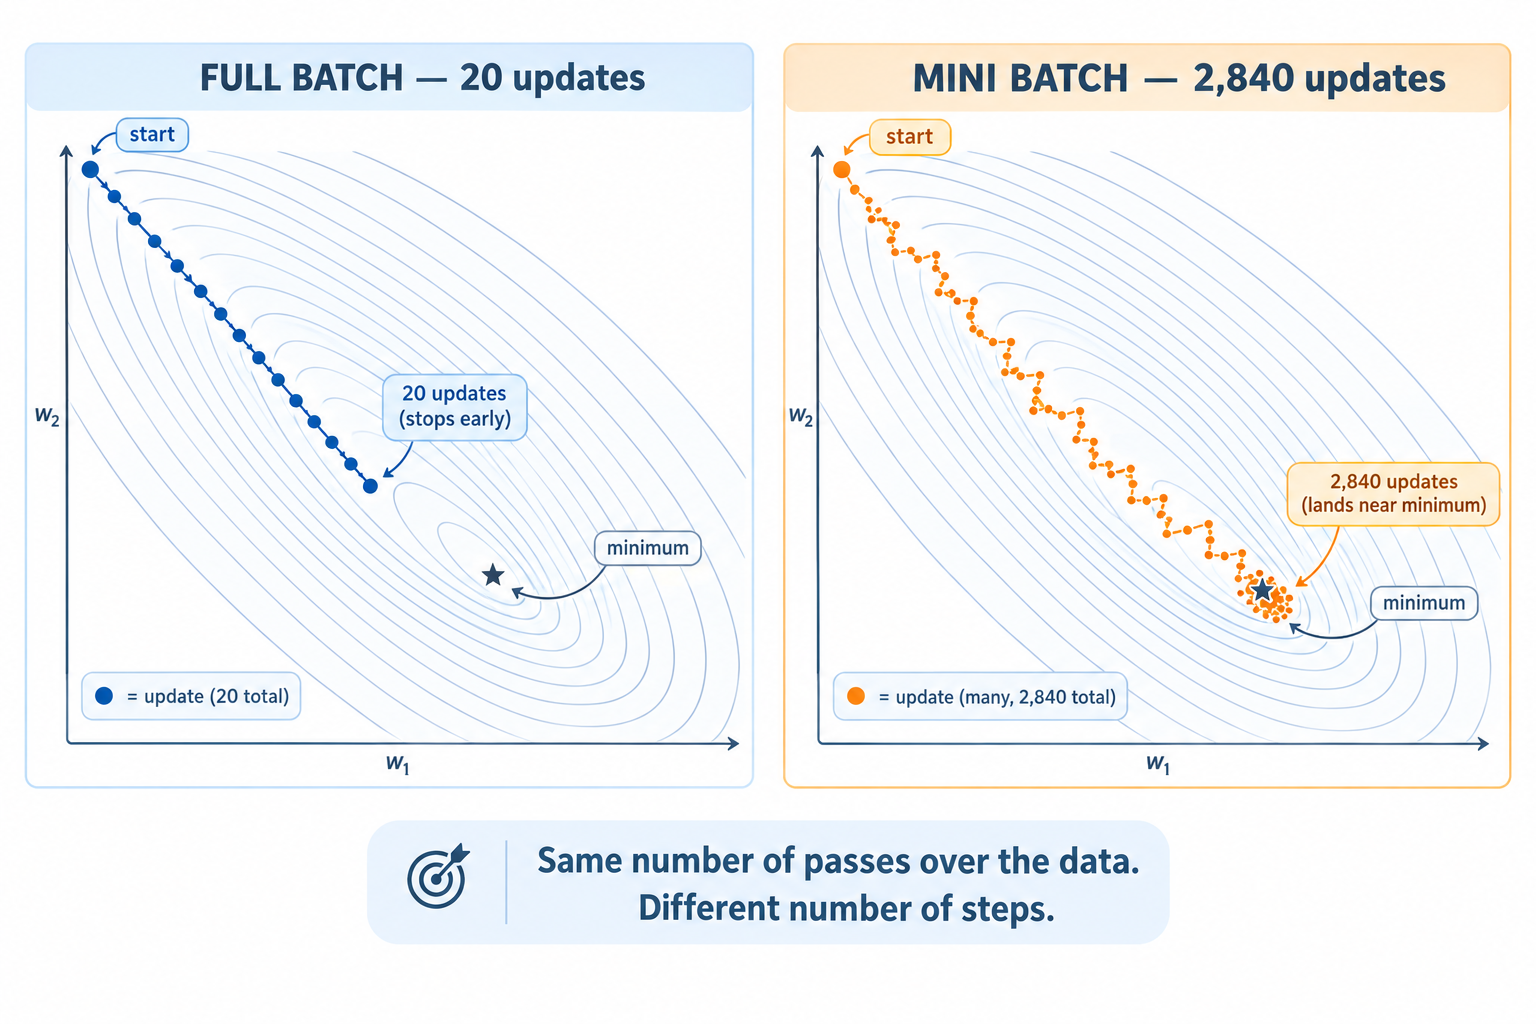


</div>

**Questions to sit with:**

1. Mini-batching took several times longer in wall-clock terms for the same twenty epochs. Where
   did that time go, given that both runs did the same total amount of arithmetic on the same data?
2. If you doubled `batch_size` from 256 to 512 and kept everything else fixed, predict what
   happens to: updates per epoch, gradient noise, wall-clock time per epoch, and final ROC-AUC.
   Which of the four are you confident about?
3. At what dataset size would full-batch training stop being possible on a 15 GB GPU for this
   50-feature tabular problem? Does that number surprise you?

## 2. Splitting before you touch anything

The order of operations in a data pipeline matters because it determines whether your validation and test results are trustworthy.

The rule is:

> **Split the data first. Then learn preprocessing rules using the training split only.**

Suppose we want to standardise a feature.

Standardisation means:

```text
new value = (old value - mean) / standard deviation
```

If we calculate the mean and standard deviation using **all** the data, the calculation includes the validation and test examples.

That means information from the held-out data has influenced the numbers used to prepare the training data.

The model has not directly seen the validation labels, but the preprocessing step has still used information from the validation data.

That is a form of **data leakage**.

The safe sequence is:

```text
1. Split the data
        ↓
2. Calculate preprocessing values from TRAIN only
        ↓
3. Transform TRAIN using those values
        ↓
4. Transform VALIDATION using the SAME values
        ↓
5. Transform TEST using the SAME values
```

For example:

```python
X_tr, X_va = split(X)

scaler.fit(X_tr)

X_tr = scaler.transform(X_tr)
X_va = scaler.transform(X_va)
```

Notice that we do **not** call `scaler.fit()` on `X_va`.

The validation set is supposed to behave like unseen data.


In [16]:
from sklearn.preprocessing import StandardScaler

y_all = (bank["y"] == "yes").astype(np.int64).values
X_all = bank.drop(columns=["y"])

# Split into train / validation / test. 70 / 15 / 15, stratified on the target
# so all three splits carry the same 11.7% positive rate.
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED
)
X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

for name, X_, y_ in [("train", X_tr, y_tr), ("val", X_va, y_va), ("test", X_te, y_te)]:
    print(f"{name:<6} {X_.shape[0]:>6,} rows | positive rate {y_.mean():.4f}")

print(f"\nTotal: {len(y_tr) + len(y_va) + len(y_te):,} (of {len(y_all):,})")

train  31,647 rows | positive rate 0.1170
val     6,782 rows | positive rate 0.1171
test    6,782 rows | positive rate 0.1169

Total: 45,211 (of 45,211)


`stratify=y_all` tells `train_test_split` to preserve approximately the same class proportions in each split.

Our target has two classes:

```text
yes → client subscribed
no  → client did not subscribe
```

If the complete dataset contains about 11.7% `yes` and 88.3% `no`, stratification aims to keep roughly that same proportion in the training, validation, and test sets.

This is useful because a random split without stratification can accidentally produce slightly different class balances.

Important distinction:

> **Stratification controls class proportions. It does not solve every possible problem with how a dataset should be split.**

For example, if the same person appears many times, or if rows from the same patient belong together, we may need a group-based split instead. We will return to that idea later.


In [17]:
numeric_cols = [c for c in X_all.columns if X_all[c].dtype.kind in "iuf"]
print("Numeric columns:", numeric_cols)

correct_scaler = StandardScaler().fit(X_tr[numeric_cols])       # train only
leaked_scaler = StandardScaler().fit(X_all[numeric_cols])       # everything

comparison = pd.DataFrame({
    "correct_mean": correct_scaler.mean_,
    "leaked_mean": leaked_scaler.mean_,
    "correct_scale": correct_scaler.scale_,
    "leaked_scale": leaked_scaler.scale_,
}, index=numeric_cols)
comparison["mean_shift_pct"] = (
    100 * (comparison.leaked_mean - comparison.correct_mean).abs()
    / comparison.correct_mean.abs().clip(lower=1e-9)
)
print()
print(comparison.round(3).to_string())

Numeric columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

          correct_mean  leaked_mean  correct_scale  leaked_scale  mean_shift_pct
age             40.883       40.936         10.622        10.619           0.130
balance       1363.590     1362.272       3070.187      3044.732           0.097
day             15.807       15.806          8.331         8.322           0.002
campaign         2.760        2.764          3.105         3.098           0.138
pdays           39.869       40.198         99.673       100.128           0.824
previous         0.585        0.580          2.491         2.303           0.765


The difference between the correctly calculated scaling statistics and the leaked statistics is small here.

That is actually an important lesson.

**Data leakage does not have to produce an obviously ridiculous result.** It can make a validation score look only slightly better while still making the evaluation method incorrect.

A code review should care about whether the pipeline is logically correct, not only whether the mistake changes today's number by a lot.

The safe pattern is always:

```python
X_tr, X_va = split(X)          # split first
scaler.fit(X_tr)               # learn preprocessing from train only
X_tr = scaler.transform(X_tr)  # transform train
X_va = scaler.transform(X_va)  # transform validation with same scaler
```

Do not fit a second scaler on validation or test data.

**Questions to sit with**

1. Why might a tiny amount of leakage have almost no practical effect on this particular dataset, yet still be unacceptable in a production pipeline?
2. If several rows belong to the same patient, why might putting some rows in training and other rows in validation make the validation score overly optimistic?


## 3. Encoding a real table

A neural network ultimately needs numbers.

For this note, we want to give the model a matrix shaped like:

```text
(N, F)
```

where:

- `N` = number of examples;
- `F` = number of input features.

For example:

```text
(36,168, 50)
```

means:

- 36,168 training examples;
- 50 numerical input features for each example.

The Bank Marketing dataset contains both **numeric** and **categorical** columns, so we cannot simply pass the original table directly to a neural network.

We need to decide how each type of column should become numbers.

In [18]:
categorical_cols = [c for c in X_all.columns if c not in numeric_cols]

print(f"Numeric     ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print()
for c in categorical_cols:
    vals = X_all[c].unique()
    shown = ", ".join(map(str, vals[:5])) + (" ..." if len(vals) > 5 else "")
    print(f"  {c:<12} {len(vals):>2} levels: {shown}")

Numeric     (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

  job          12 levels: management, technician, entrepreneur, blue-collar, unknown ...
  marital       3 levels: married, single, divorced
  education     4 levels: tertiary, secondary, unknown, primary
  default       2 levels: no, yes
  housing       2 levels: yes, no
  loan          2 levels: no, yes
  contact       3 levels: unknown, cellular, telephone
  month        12 levels: may, jun, jul, aug, oct ...
  poutcome      4 levels: unknown, failure, other, success


### Why not just number the categories?

Suppose the `job` column contains:

```text
admin.
blue-collar
management
retired
student
```

A tempting solution is:

```text
admin.       → 0
blue-collar  → 1
management   → 2
retired      → 3
student      → 4
```

The problem is that these numbers create a fake meaning.

The model sees `4` and `3` as numbers, so it can learn that `4` is larger than `3`, and that the distance from `0` to `4` is four times the distance from `0` to `1`.

But there is no natural numerical distance between job categories.

`student` is not "twice as much job" as `management`.

For **nominal categories**—categories that are names rather than ordered quantities—we therefore usually use **one-hot encoding**.

One-hot encoding creates one indicator column for each category:

```text
job=admin.       job=blue-collar  job=management  ...
     1                  0               0
     0                  1               0
     0                  0               1
```

Each row has a `1` for its category and `0` for the others.

This gives the model category membership without inventing an ordering.


In [19]:
demo = pd.DataFrame({"job": ["admin.", "blue-collar", "management", "retired", "student"]})

ordinal = demo.copy()
ordinal["job_code"] = pd.factorize(demo["job"])[0]
print("Ordinal encoding — invents an ordering:")
print(ordinal.to_string(index=False))
print("\n  It now claims |admin. - student| = 4 and |admin. - blue-collar| = 1.")
print("  Neither statement means anything.")

onehot = pd.get_dummies(demo, columns=["job"]).astype(int)
print("\nOne-hot encoding — every category equidistant from every other:")
print(onehot.to_string(index=False))

Ordinal encoding — invents an ordering:
        job  job_code
     admin.         0
blue-collar         1
 management         2
    retired         3
    student         4

  It now claims |admin. - student| = 4 and |admin. - blue-collar| = 1.
  Neither statement means anything.

One-hot encoding — every category equidistant from every other:
 job_admin.  job_blue-collar  job_management  job_retired  job_student
          1                0               0            0            0
          0                1               0            0            0
          0                0               1            0            0
          0                0               0            1            0
          0                0               0            0            1


One-hot encoding is a good default for the relatively small categorical columns in this dataset.

The trade-off is that one categorical column can become several numerical columns. Nine categorical columns therefore expand the input matrix from the original table to roughly 44 indicator columns.

For a much larger number of categories, another approach is a **learned embedding**.

An embedding gives each category a small trainable vector instead of creating a separate 0/1 column for every category. Language models use the same general idea when they turn token IDs into vectors.

For this note, one-hot encoding is simpler and completely adequate.

One subtle exception is `month`. Months have a natural order and also form a cycle: December is next to January. Treating them as ordinary categories loses that structure. We keep one-hot encoding here for simplicity, but it is a useful feature-engineering idea to revisit later.

### The full encoding pipeline

The goal is to turn the mixed table into:

```text
a clean float32 matrix
        ↓
that the neural network can accept directly
```


In [21]:
def encode_features(
    X_train: pd.DataFrame,
    X_others: dict,
    numeric: list,
    categorical: list,
):
    """One-hot the categoricals, standardise the numerics, using TRAIN statistics only.

    Returns (encoded_train, {name: encoded_other}, feature_names).
    """
    # One-hot on the union of columns so every split ends up with identical columns,
    # then reindex the others against the training columns. A category that appears
    # only in validation becomes an all-zero column rather than a new one.
    train_ohe = pd.get_dummies(X_train, columns=categorical)
    feature_names = list(train_ohe.columns)

    scaler = StandardScaler().fit(train_ohe[numeric])

    def finish(df_ohe):
        df_ohe = df_ohe.reindex(columns=feature_names, fill_value=0)
        df_ohe = df_ohe.astype(np.float32)
        df_ohe[numeric] = scaler.transform(df_ohe[numeric]).astype(np.float32)
        return df_ohe.values.astype(np.float32)

    out_train = finish(train_ohe)
    out_others = {
        name: finish(pd.get_dummies(df, columns=categorical))
        for name, df in X_others.items()
    }
    return out_train, out_others, feature_names

In [22]:
Xtr_enc, others, feature_names = encode_features(
    X_tr, {"val": X_va, "test": X_te}, numeric_cols, categorical_cols
)

In [26]:
X_tr

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
13382,31,services,married,secondary,no,1,yes,no,cellular,9,jul,1,-1,0,unknown
32641,35,services,married,secondary,no,195,yes,no,cellular,17,apr,1,-1,0,unknown
3991,24,blue-collar,single,secondary,no,77,yes,no,unknown,16,may,2,-1,0,unknown
8068,35,blue-collar,married,secondary,no,80,yes,yes,unknown,2,jun,2,-1,0,unknown
27484,37,services,single,secondary,no,105,no,yes,cellular,21,nov,2,157,4,failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16952,45,blue-collar,married,secondary,no,79,yes,no,cellular,25,jul,1,-1,0,unknown
6317,30,blue-collar,married,secondary,no,1196,no,no,unknown,27,may,1,-1,0,unknown
34781,27,management,single,tertiary,no,2559,yes,no,cellular,6,may,1,-1,0,unknown
13679,32,housemaid,married,primary,no,0,yes,no,cellular,9,jul,1,-1,0,unknown


In [27]:
Xva_enc, Xte_enc = others["val"], others["test"]

In [28]:
Xva_enc.shape

(6782, 50)

In [29]:
print(f"train {Xtr_enc.shape}  dtype {Xtr_enc.dtype}")
print(f"val   {Xva_enc.shape}")
print(f"test  {Xte_enc.shape}")
print(f"\n{len(numeric_cols)} numeric + {len(categorical_cols)} categorical "
      f"-> {Xtr_enc.shape[1]} columns")
print(f"\nFirst 12 feature names: {feature_names[:12]}")

train (31647, 50)  dtype float32
val   (6782, 50)
test  (6782, 50)

6 numeric + 9 categorical -> 50 columns

First 12 feature names: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired']


In [30]:
# Verify the contract before going any further.
assert Xtr_enc.dtype == np.float32, "network inputs must be float32"
assert Xtr_enc.shape[1] == Xva_enc.shape[1] == Xte_enc.shape[1], "splits must agree on width"
assert not np.isnan(Xtr_enc).any(), "no NaNs"
assert np.isfinite(Xtr_enc).all(), "no infinities"

train_numeric_means = Xtr_enc[:, [feature_names.index(c) for c in numeric_cols]].mean(axis=0)
print("Standardised numeric columns, training-set means (should be ~0):")
print("  ", train_numeric_means.round(6))

val_numeric_means = Xva_enc[:, [feature_names.index(c) for c in numeric_cols]].mean(axis=0)
print("\nSame columns on validation (NOT exactly 0 — and that is correct):")
print("  ", val_numeric_means.round(4))
print("\nIf validation means were exactly zero, the scaler had seen validation data.")

Standardised numeric columns, training-set means (should be ~0):
   [-0.  0.  0.  0. -0. -0.]

Same columns on validation (NOT exactly 0 — and that is correct):
   [-0.      0.0101  0.0103  0.0088  0.0108 -0.0108]

If validation means were exactly zero, the scaler had seen validation data.


That final check is useful because the validation data should **not** have been used to learn its own scaling statistics.

If the validation features have exactly zero mean and unit standard deviation because you fitted a scaler directly on the validation set, that is a warning sign.

The validation set should be transformed using the scaler learned from training data.

### Check the class balance before looking at accuracy

Before evaluating a classifier, always ask:

> **How common is the positive class?**

Here, "positive" means the client subscribed to the term deposit.

If only 11.7% of examples are positive, then 88.3% are negative.

A model that simply predicts:

```text
"no" for everyone
```

would already achieve 88.3% accuracy.

That does not mean the model has learned anything useful.

This is why class balance should be understood **before** interpreting accuracy.

Positive class rate  : 0.1170  (11.7%)
Negative class rate  : 0.8830  (88.3%)

A model that outputs 'no' for every single client scores 88.3% accuracy
and is worth nothing, because it identifies zero of the 3,702 clients who would subscribe.


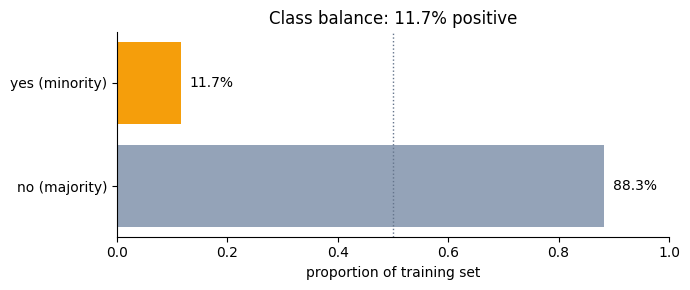

In [31]:
pos_rate = y_tr.mean()
majority_accuracy = 1 - pos_rate

print(f"Positive class rate  : {pos_rate:.4f}  ({pos_rate * 100:.1f}%)")
print(f"Negative class rate  : {majority_accuracy:.4f}  ({majority_accuracy * 100:.1f}%)")
print()
print(f"A model that outputs 'no' for every single client scores "
      f"{majority_accuracy * 100:.1f}% accuracy")
print(f"and is worth nothing, because it identifies zero of the "
      f"{y_tr.sum():,} clients who would subscribe.")

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(["no (majority)", "yes (minority)"], [1 - pos_rate, pos_rate],
        color=["#94a3b8", "#f59e0b"])
ax.axvline(0.5, color="#64748b", linestyle=":", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("proportion of training set")
ax.set_title(f"Class balance: {pos_rate * 100:.1f}% positive")
for i, v in enumerate([1 - pos_rate, pos_rate]):
    ax.text(v + 0.015, i, f"{v * 100:.1f}%", va="center", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Accuracy is misleading for this dataset because the negative class is much more common than the positive class.

Two metrics used here are more informative:

- **ROC-AUC:** measures how well the model ranks positive examples above negative examples. A useful way to think about it is: if we randomly choose one subscriber and one non-subscriber, how often does the model give the subscriber the higher score?
- **Average precision (PR-AUC):** focuses on precision and recall for the positive class. This is useful when the positive class is relatively rare.

A useful fact about average precision is that its baseline depends on the positive-class rate. Here, that baseline is around 0.117 rather than 0.5.

We will use these metrics later rather than treating accuracy as the headline result.

**Questions to sit with**

1. What should happen if a category appears in the test set but never appeared in training?
2. Why might one-hot encoding with all category columns be easier to reason about in a neural-network pipeline than removing the first category column?


## 4. The Dataset protocol

A PyTorch `Dataset` is simply an object that knows how to answer two questions:

```python
len(dataset)
```

> **How many examples are available?**

and:

```python
dataset[i]
```

> **Give me example number `i`.**

In a custom PyTorch dataset, these are normally implemented as:

```python
def __len__(self):
    return number_of_examples

def __getitem__(self, i):
    return one_example
```

This is called a **protocol**: a small set of methods that an object agrees to provide so that other PyTorch components know how to use it.

The important point is that PyTorch does not care where the example comes from.

It could come from:

- a tensor already in RAM;
- a CSV file;
- an image on disk;
- an audio file;
- a database;
- an API;
- or another source.

As long as the dataset can answer "how many examples?" and "give me example `i`", it can be used as a PyTorch `Dataset`.


### Put the feature matrix into a PyTorch tensor

`Xtr_enc` is a NumPy array containing the encoded training features.

`torch.from_numpy(...)` creates a PyTorch tensor that uses the same underlying data when possible.

We do this because PyTorch models and training operations work with PyTorch tensors.


In [33]:
Xtr_enc

array([[-0.930461  , -0.4438132 , -0.8170392 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.55387133, -0.3806249 ,  0.14323561, ...,  0.        ,
         0.        ,  1.        ],
       [-1.5894929 , -0.419059  ,  0.02320126, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.3070506 ,  0.38936085, -1.1771423 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.83631355, -0.4441389 , -0.8170392 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.08313424, -0.25489965, -0.09683309, ...,  0.        ,
         0.        ,  1.        ]], shape=(31647, 50), dtype=float32)

In [35]:
Xtr_t = torch.from_numpy(Xtr_enc)
ytr_t = torch.from_numpy(y_tr).float().unsqueeze(1)      # (N, 1) to match a 1-logit output

Xva_t = torch.from_numpy(Xva_enc)
yva_t = torch.from_numpy(y_va).float().unsqueeze(1)

Xte_t = torch.from_numpy(Xte_enc)
yte_t = torch.from_numpy(y_te).float().unsqueeze(1)

In [36]:
ytr_t

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]])

### Create a simple Dataset

`TensorDataset` is PyTorch's ready-made dataset for tensors.

Here it receives:

```text
Xtr_t → training features
ytr_t → training labels
```

For index `i`, it returns:

```python
(Xtr_t[i], ytr_t[i])
```

So it already implements the `__len__` and `__getitem__` behaviour we need.


In [37]:
train_ds = TensorDataset(Xtr_t, ytr_t)
val_ds = TensorDataset(Xva_t, yva_t)
test_ds = TensorDataset(Xte_t, yte_t)

In [39]:
print(f"len(train_ds) = {len(train_ds):,}")

len(train_ds) = 31,647


In [42]:
len(val_ds)

6782

In [53]:
train_ds[52]

(tensor([ 1.1408, -0.4441, -0.0968,  0.7214, -0.4100, -0.2348,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,
          0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  1.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  1.0000]),
 tensor([0.]))

In [48]:
x0, y0 = train_ds[0:]
print(f"\ntrain_ds[0] returns a tuple of {len((x0, y0))}:")


train_ds[0] returns a tuple of 2:


In [49]:
x0

tensor([-0.9305, -0.4438, -0.8170, -0.5668, -0.4100, -0.2348,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,
         0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  1.0000])

In [50]:
y0

tensor([0.])

In [54]:
print(f"  features : shape {tuple(x0.shape)}, dtype {x0.dtype}")
print(f"  label    : shape {tuple(y0.shape)}, dtype {y0.dtype}, value {y0.item()}")
print("\nNote: __getitem__ returns ONE example, with no batch axis.")
print("Adding the batch axis is the DataLoader's job, not yours.")

  features : shape (50,), dtype torch.float32
  label    : shape (1,), dtype torch.float32, value 0.0

Note: __getitem__ returns ONE example, with no batch axis.
Adding the batch axis is the DataLoader's job, not yours.


In [ ]:
for i in train_ds:
    print(i)

This separation explains the job of each object.

**`Dataset` answers:**

> "What is example number `i`?"

**`DataLoader` answers:**

> "Which examples should I request, and how should I group them into batches?"

For example:

```text
Dataset
  ↓
example 0
example 1
example 2
...
example 36,167

DataLoader
  ↓
batch 1: examples 0–255
batch 2: examples 256–511
...
```

Because these responsibilities are separate, you can use the same `Dataset` with different batch sizes:

```python
DataLoader(train_ds, batch_size=32)
DataLoader(train_ds, batch_size=256)
DataLoader(train_ds, batch_size=1024)
```

The dataset does not need to change.


### Writing one yourself

`TensorDataset` is convenient when your data is already stored in tensors.

You write your own `Dataset` when you need the dataset to **do something while producing an example**.

Common reasons include:

- reading an image from disk;
- applying an augmentation;
- normalising an example;
- reading an audio file;
- returning several pieces of information;
- performing a transformation that you do not want to calculate for the entire dataset ahead of time.

The key idea is:

> **`__getitem__` is where you define how one example is obtained and prepared.**

### A custom `Dataset`

Here we write the same idea ourselves.

The class stores the features and labels, then defines:

- `__len__` → number of examples;
- `__getitem__(i)` → feature and label for example `i`.

Writing it ourselves gives us a place to add extra behaviour, such as noise or transformations.


In [56]:
class BankMarketingDataset(Dataset):
    """Tabular Dataset over pre-encoded arrays, with an optional per-example transform."""

    def __init__(self, features: np.ndarray, labels: np.ndarray, noise_std: float = 0.0):
        assert len(features) == len(labels), "features and labels must align"
        self.features = torch.from_numpy(np.asarray(features, dtype=np.float32))
        self.labels = torch.from_numpy(np.asarray(labels, dtype=np.float32)).unsqueeze(1)
        self.noise_std = noise_std

    def __len__(self) -> int:
        return self.features.shape[0]

    def __getitem__(self, idx: int):
        x = self.features[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std     # augmentation, train only
        return x, self.labels[idx]

In [57]:
custom_ds = BankMarketingDataset(Xtr_enc, y_tr)
print(f"len          : {len(custom_ds):,}")
x0, y0 = custom_ds[0]
print(f"example 0    : x {tuple(x0.shape)} {x0.dtype}, y {tuple(y0.shape)} {y0.item()}")

len          : 31,647
example 0    : x (50,) torch.float32, y (1,) 0.0


In [65]:
noisy_ds = BankMarketingDataset(Xtr_enc, y_tr, noise_std=0.1)
a, _ = noisy_ds[0]
b, _ = noisy_ds[0]
print(f"\nWith noise_std=0.1, the SAME index returns different values each call:")
print(f"  first  call, first 4 features: {a[:4].numpy().round(3)}")
print(f"  second call, first 4 features: {b[:4].numpy().round(3)}")
print("\nThis is how augmentation works: __getitem__ is called fresh every epoch.")


With noise_std=0.1, the SAME index returns different values each call:
  first  call, first 4 features: [-0.916 -0.472 -0.815 -0.657]
  second call, first 4 features: [-0.851 -0.386 -0.83  -0.702]

This is how augmentation works: __getitem__ is called fresh every epoch.


**Questions to sit with**

1. `__getitem__` returns a tuple `(x, y)` in this example, but PyTorch does not require that exact format. If a model needs an image, a text caption, and a label, you could return something like `(image, caption, label)`. The training loop would then unpack those three values.
2. A training dataset can intentionally produce slightly different versions of an example—for example, by adding random noise or shifting an image. This can help the model generalise. A validation dataset should normally return a stable version of the same example so that its score can be compared fairly from one evaluation to the next.


## 5. A `Dataset` that reads from disk

So far, the examples have already been stored in RAM.

That is convenient, but real datasets can be much larger than available memory.

Imagine a dataset containing:

```text
1,000,000 images
```

It may be wasteful or impossible to load every image into RAM before training.

Instead, we can store the files on disk and have the `Dataset` read an image **only when that image is requested**.

This is called **lazy loading**.

```text
Dataset created
     ↓
store file paths
     ↓
training asks for example 153
     ↓
read image 153 from disk
     ↓
return image
```

The image does not have to remain in memory as part of the entire dataset.

We will demonstrate this using scikit-learn's small `load_digits` dataset. The examples are written as PNG files first so that we can practise the same pattern used by much larger image datasets.

The folder structure uses one directory per class, which is also the convention expected by `torchvision.datasets.ImageFolder`.

Everything so far had the data in RAM already, which makes `Dataset` look like a formality. The
protocol earns its keep when the data does *not* fit — 100,000 images, a directory of audio files,
a set of documents too large to hold at once.

To make this concrete rather than hypothetical, we will write scikit-learn's `load_digits` out as
individual PNG files in a folder tree, then read them back one at a time. The dataset is small
enough to run anywhere and the pattern is identical to what you would use for a million images.

The folder layout below — one directory per class — is the near-universal convention, and it is
what `torchvision.datasets.ImageFolder` expects.

In [58]:
from sklearn.datasets import load_digits
from PIL import Image

DIGITS_ROOT = DATA_DIR / "digits_png"

In [65]:
digits = load_digits()
digits['images']

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [68]:
def export_digits_to_png(root: Path = DIGITS_ROOT, seed: int = SEED) -> Path:
    """Write load_digits out as one PNG per image, in class subdirectories."""
    if root.exists() and any(root.rglob("*.png")):
        print(f"Already exported at {root}")
        return root

    digits = load_digits()
    n = len(digits.images)
    rng = np.random.default_rng(seed)
    order = rng.permutation(n)
    cut = int(0.8 * n)

    for split in ("train", "val"):
        for cls in range(10):
            (root / split / str(cls)).mkdir(parents=True, exist_ok=True)

    for position, idx in enumerate(order):
        split = "train" if position < cut else "val"
        # load_digits stores 0-16 greyscale; PNG wants 0-255 uint8.
        arr = (digits.images[idx] / 16.0 * 255).astype(np.uint8)
        label = digits.target[idx]
        Image.fromarray(arr, mode="L").save(root / split / str(label) / f"{idx:04d}.png")

    return root

In [69]:
t0 = time.time()
export_digits_to_png()
n_files = len(list(DIGITS_ROOT.rglob("*.png")))
print(f"{n_files:,} PNG files written in {time.time() - t0:.1f}s")
print(f"\nLayout:")
print(f"  {DIGITS_ROOT}/")
print(f"    train/0/*.png  train/1/*.png  ...  train/9/*.png")
print(f"    val/0/*.png    val/1/*.png    ...  val/9/*.png")
print(f"\ntrain files: {len(list((DIGITS_ROOT / 'train').rglob('*.png'))):,}")
print(f"val files  : {len(list((DIGITS_ROOT / 'val').rglob('*.png'))):,}")

Already exported at data/digits_png
1,800 PNG files written in 0.0s

Layout:
  data/digits_png/
    train/0/*.png  train/1/*.png  ...  train/9/*.png
    val/0/*.png    val/1/*.png    ...  val/9/*.png

train files: 1,440
val files  : 360


### A Dataset that reads image files

This custom dataset does not store all image pixels in one large tensor.

Instead, it stores the locations of the image files. When `__getitem__(i)` is called, it opens the corresponding file, converts it into a tensor, and returns the image and its label.

That is the basic pattern behind many real-world image datasets.


In [70]:
class DigitImageFolder(Dataset):
    """Reads PNG files lazily. Only the file paths live in memory, never the pixels."""

    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        # Scan the directory ONCE, at construction, and keep only paths + labels.
        self.samples: list[tuple[Path, int]] = []
        for class_dir in sorted(self.root.iterdir()):
            if not class_dir.is_dir():
                continue
            label = int(class_dir.name)
            for png in sorted(class_dir.glob("*.png")):
                self.samples.append((png, label))
        if not self.samples:
            raise RuntimeError(f"No PNG files found under {self.root}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]
        with Image.open(path) as img:                 # the disk read happens HERE
            arr = np.array(img, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).unsqueeze(0)        # (H, W) -> (C=1, H, W)
        if self.transform is not None:
            x = self.transform(x)
        return x, label

In [71]:
digit_train = DigitImageFolder(DIGITS_ROOT / "train")
digit_val = DigitImageFolder(DIGITS_ROOT / "val")

print(f"train: {len(digit_train):,} images | val: {len(digit_val):,} images")

x0, y0 = digit_train[0]
print(f"\ndigit_train[0]:")
print(f"  x shape {tuple(x0.shape)}  dtype {x0.dtype}  range [{x0.min():.2f}, {x0.max():.2f}]")
print(f"  y = {y0} (a plain Python int, not a tensor — the DataLoader will collate it)")

import sys as _sys
paths_bytes = _sys.getsizeof(digit_train.samples)
print(f"\nMemory held by the Dataset object: roughly {paths_bytes / 1024:.1f} KB of paths.")
print("The pixels are read from disk on demand and discarded after each batch.")

train: 1,437 images | val: 360 images

digit_train[0]:
  x shape (1, 8, 8)  dtype torch.float32  range [0.00, 0.94]
  y = 0 (a plain Python int, not a tensor — the DataLoader will collate it)

Memory held by the Dataset object: roughly 12.4 KB of paths.
The pixels are read from disk on demand and discarded after each batch.


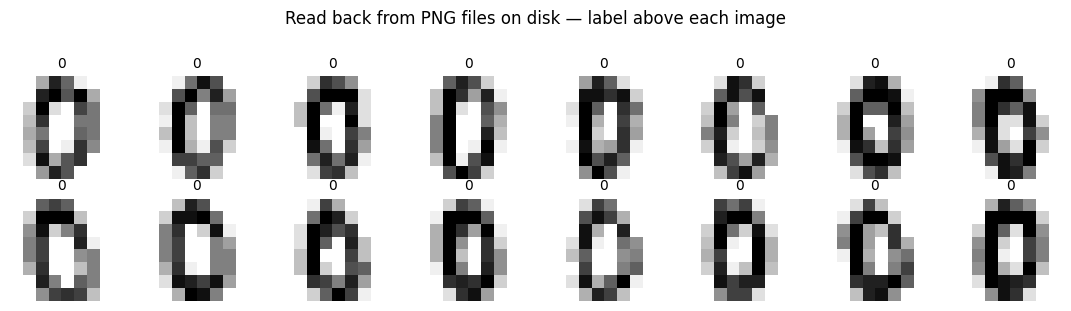

In [72]:
# Confirm the labels actually match the images.
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, i in zip(axes.ravel(), range(16)):
    img, lab = digit_train[i]
    ax.imshow(img.squeeze(0).numpy(), cmap="gray_r")
    ax.set_title(str(lab), fontsize=10)
    ax.axis("off")
fig.suptitle("Read back from PNG files on disk — label above each image", y=1.02)
plt.tight_layout()
plt.show()

### Transforms belong in `__getitem__`

A **transform** is simply a function that changes an example before it is returned.

For example:

```text
image
  ↓
resize
  ↓
normalise
  ↓
randomly shift
  ↓
return image
```

Putting the transform inside `__getitem__` means it is applied whenever that example is requested.

This matters for random augmentation.

Suppose example `0` is randomly shifted:

```text
first request → shift left
second request → shift right
third request → no shift
```

The underlying image file has not changed. We are creating different training versions of the same example.

That is useful for **training augmentation**.

For validation, we normally avoid random transformations because we want evaluation to be stable.


### Define the transformations

The functions below are small building blocks:

- `normalise(...)` changes the numerical scale of an image;
- `random_shift(...)` moves the image by a random number of pixels;
- `compose(...)` applies several transformations in sequence.

Because these transformations are called from `__getitem__`, they are applied when an example is requested.


In [76]:
def normalise(mean: float, std: float):
    """Standardise pixel values. Deterministic — safe for train and validation alike."""
    def apply(x: torch.Tensor) -> torch.Tensor:
        return (x - mean) / std
    return apply


def random_shift(max_pixels: int = 1):
    """Randomly translate the image. Stochastic — TRAIN ONLY."""
    def apply(x: torch.Tensor) -> torch.Tensor:
        dy = int(torch.randint(-max_pixels, max_pixels + 1, (1,)).item())
        dx = int(torch.randint(-max_pixels, max_pixels + 1, (1,)).item())
        return torch.roll(x, shifts=(dy, dx), dims=(1, 2))
    return apply


def compose(*fns):
    def apply(x):
        for fn in fns:
            x = fn(x)
        return x
    return apply

In [77]:
# Compute normalisation statistics from the TRAINING split only — the same rule as Section 2.
sample = torch.stack([digit_train[i][0] for i in range(len(digit_train))])
sample

tensor([[[[0.0000, 0.0000, 0.3098,  ..., 0.0588, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.8118,  ..., 0.9373, 0.3098, 0.0000],
          [0.0000, 0.1843, 0.9373,  ..., 0.6863, 0.4980, 0.0000],
          ...,
          [0.0000, 0.2471, 0.6863,  ..., 0.7490, 0.4353, 0.0000],
          [0.0000, 0.1216, 0.8745,  ..., 0.7490, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.3725,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0588,  ..., 0.6863, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.6863,  ..., 0.8745, 0.3725, 0.0000],
          [0.0000, 0.1216, 1.0000,  ..., 0.5608, 0.5608, 0.0000],
          ...,
          [0.0000, 0.0588, 1.0000,  ..., 0.6863, 0.1843, 0.0000],
          [0.0000, 0.0000, 0.7490,  ..., 0.6235, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0588,  ..., 0.1843, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.1843,  ..., 0.4353, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.6863,  ..., 1.0000, 0.1216, 0.0000],
          [0.0000, 0.2471, 1.0000,  ..

In [78]:
px_mean, px_std = sample.mean().item(), sample.std().item()
print(f"Training pixel mean {px_mean:.4f}, std {px_std:.4f}")

Training pixel mean 0.3043, std 0.3757


In [79]:
digit_train_aug = DigitImageFolder(
    DIGITS_ROOT / "train",
    transform=compose(random_shift(1), normalise(px_mean, px_std)),
)

digit_train_aug 

In [80]:
digit_val_norm = DigitImageFolder(
    DIGITS_ROOT / "val",
    transform=normalise(px_mean, px_std),      # no random shift on validation
)

digit_val_norm

In [82]:
a, _ = digit_train_aug[0]
a

tensor([[[-0.8099, -0.8099, -0.8099,  1.3508,  1.6848,  0.8498,  1.6848,
           0.0147],
         [-0.8099, -0.8099, -0.3193,  1.6848, -0.4863, -0.8099,  1.0168,
           0.5157],
         [-0.8099, -0.8099, -0.1523,  1.1838, -0.8099, -0.8099,  0.5157,
           0.5157],
         [-0.8099, -0.8099,  0.0147,  0.5157, -0.8099, -0.8099,  0.6827,
           0.5157],
         [-0.8099, -0.8099, -0.1523,  1.0168, -0.8099, -0.6533,  1.1838,
           0.3487],
         [-0.8099, -0.8099, -0.4863,  1.5178,  0.0147,  0.8498,  1.1838,
          -0.8099],
         [-0.8099, -0.8099, -0.8099,  0.1817,  1.3508,  0.8498, -0.8099,
          -0.8099],
         [-0.8099, -0.8099, -0.8099,  0.0147,  1.3508,  0.6827, -0.6533,
          -0.8099]]])

In [83]:
b, _ = digit_train_aug[0]
b

tensor([[[-0.8099, -0.8099, -0.8099,  0.0147,  1.3508,  0.6827, -0.6533,
          -0.8099],
         [-0.8099, -0.8099, -0.8099,  1.3508,  1.6848,  0.8498,  1.6848,
           0.0147],
         [-0.8099, -0.8099, -0.3193,  1.6848, -0.4863, -0.8099,  1.0168,
           0.5157],
         [-0.8099, -0.8099, -0.1523,  1.1838, -0.8099, -0.8099,  0.5157,
           0.5157],
         [-0.8099, -0.8099,  0.0147,  0.5157, -0.8099, -0.8099,  0.6827,
           0.5157],
         [-0.8099, -0.8099, -0.1523,  1.0168, -0.8099, -0.6533,  1.1838,
           0.3487],
         [-0.8099, -0.8099, -0.4863,  1.5178,  0.0147,  0.8498,  1.1838,
          -0.8099],
         [-0.8099, -0.8099, -0.8099,  0.1817,  1.3508,  0.8498, -0.8099,
          -0.8099]]])

In [84]:
print(f"\nSame index, two calls, augmented dataset — identical? "
      f"{torch.equal(a, b)}  (expected False)")


Same index, two calls, augmented dataset — identical? False  (expected False)


In [85]:
c, _ = digit_val_norm[0]
d, _ = digit_val_norm[0]
print(f"Same index, two calls, validation dataset  — identical? "
      f"{torch.equal(c, d)}  (expected True)")

Same index, two calls, validation dataset  — identical? True  (expected True)


The output demonstrates an important rule:

> **Random transforms belong in training; validation transforms should be deterministic.**

If validation randomly changes every time it is evaluated, then a change in validation performance could be caused by the model—or simply by the validation images being different.

That makes the metric harder to interpret.

Training is different. Random augmentation deliberately gives the model slightly different versions of training examples so that it learns features that generalise beyond one exact presentation.


**Questions to sit with:**

1. `DigitImageFolder` scans the directory once at construction and stores paths. What breaks if
   you instead call `glob` inside `__getitem__`, and roughly how much slower would an epoch get?
2. The normalisation statistics were computed by loading every training image into one tensor —
   which defeats the purpose of lazy loading. How would you compute mean and standard deviation
   for a dataset genuinely too large to hold in memory?

## 6. DataLoader mechanics

A `Dataset` gives us individual examples.

A `DataLoader` turns those examples into **batches** that the training loop can consume.

For example, if we have 36,169 examples and choose:

```python
batch_size=256
```

the loader repeatedly gives us something like:

```text
batch 1 → 256 examples
batch 2 → 256 examples
batch 3 → 256 examples
...
final batch → fewer than 256 examples
```

The important `DataLoader` settings in this note are:

- `batch_size` — how many examples are in each batch;
- `shuffle` — whether the order of examples is randomly changed;
- `drop_last` — whether to discard a final incomplete batch;
- `num_workers` — how many separate worker processes prepare batches.

`DataLoader` takes a `Dataset` and produces batches. Its arguments are worth setting deliberately,
because three of the defaults are wrong for at least one of your two loaders.

### Create a DataLoader

Here:

```python
batch_size=256
```

means the loader tries to return 256 examples at a time.

```python
shuffle=True
```

means the order of training examples is randomly changed when a new iteration over the loader begins.

The result is a sequence of batches that the training loop can consume directly.


In [87]:
train_ds[0]

(tensor([-0.9305, -0.4438, -0.8170, -0.5668, -0.4100, -0.2348,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,
          0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  1.0000]),
 tensor([0.]))

In [89]:
loader = DataLoader(train_ds, batch_size=256, shuffle=True)

In [94]:
len(loader)

124

In [95]:
len(train_ds)

31647

In [93]:
print(f"Dataset examples : {len(train_ds):,}")
print(f"Batches per epoch: {len(loader):,}")
print(f"Check: ceil({len(train_ds):,} / 256) = "
      f"{-(-len(train_ds) // 256):,}")

for i, (xb, yb) in enumerate(loader):
    if i < 2 or i >= len(loader) - 1:
        print(f"  batch {i:>3}: x {tuple(xb.shape)}  y {tuple(yb.shape)}")
    elif i == 2:
        print("  ...")

Dataset examples : 31,647
Batches per epoch: 124
Check: ceil(31,647 / 256) = 124
  batch   0: x (256, 50)  y (256, 1)
  batch   1: x (256, 50)  y (256, 1)
  ...
  batch 123: x (159, 50)  y (159, 1)


The final batch is smaller because 36,169 is not exactly divisible by 256.

The loader therefore produces:

```text
141 full batches × 256
+ 1 smaller final batch
```

Usually, a smaller final batch is completely fine.

`drop_last=True` tells the `DataLoader` to throw that final incomplete batch away.

That can be useful during training in some situations, but it is dangerous during validation or testing because it means some examples are never evaluated.

### `shuffle`, and why it matters

A batch is the group of examples used to calculate one gradient update.

If the dataset is ordered in some meaningful way, consecutive examples may be very similar.

For example:

```text
batch 1 → mostly old campaign records
batch 2 → mostly old campaign records
batch 3 → mostly old campaign records
...
```

The gradients from these batches may repeatedly push the model in a similar direction.

Shuffling mixes the examples so that each batch is more representative of the overall training data.

We will first inspect the raw Bank Marketing file to see why this matters here.

In [97]:
raw = pd.read_csv(BANK_CSV, sep=";")
chunk = len(raw) // 6

print("The raw file, read in order, split into six consecutive chunks:\n")
print(f"  {'chunk':<7}{'commonest month':>17}{'mean pdays':>13}{'positive rate':>16}")
for i in range(6):
    part = raw.iloc[i * chunk:(i + 1) * chunk]
    print(f"  {i:<7}{part['month'].mode()[0]:>17}{part['pdays'].mean():>13.1f}"
          f"{(part['y'] == 'yes').mean():>16.3f}")

first_rate = (raw.iloc[:chunk]['y'] == 'yes').mean()
last_rate = (raw.iloc[5 * chunk:]['y'] == 'yes').mean()
print(f"\nPositive rate rises from {first_rate:.3f} to {last_rate:.3f} "
      f"across the file — a factor of {last_rate / first_rate:.0f}.")

The raw file, read in order, split into six consecutive chunks:

  chunk    commonest month   mean pdays   positive rate
  0                    may         -1.0           0.031
  1                    jun         -1.0           0.052
  2                    aug         -1.0           0.062
  3                    nov         39.0           0.058
  4                    may         99.8           0.136
  5                    may        105.5           0.363

Positive rate rises from 0.031 to 0.363 across the file — a factor of 12.


The raw file shows **distribution drift**: the characteristics of the data change as we move through the file.

In particular, the positive rate changes substantially.

If we trained directly on this ordered data without shuffling, the model could spend early updates seeing mostly negative examples and later updates seeing many more positive examples.

That means the sequence of gradient updates would be influenced by the order in which the data happened to be stored.

Shuffling breaks that dependence on the original file order.


In [98]:
ordered = DataLoader(train_ds, batch_size=256, shuffle=False)
shuffled = DataLoader(train_ds, batch_size=256, shuffle=True)


def positive_rates(dl, n=6):
    rates = []
    for i, (_, yb) in enumerate(dl):
        if i >= n:
            break
        rates.append(yb.mean().item())
    return rates


print("Positive rate in the first 6 batches of train_ds")
print(f"  shuffle=False : {[f'{r:.3f}' for r in positive_rates(ordered)]}")
print(f"  shuffle=True  : {[f'{r:.3f}' for r in positive_rates(shuffled)]}")
print(f"\n  overall training positive rate: {y_tr.mean():.3f}")
print("\nBarely any difference. The drift has vanished.")

Positive rate in the first 6 batches of train_ds
  shuffle=False : ['0.090', '0.148', '0.094', '0.164', '0.121', '0.129']
  shuffle=True  : ['0.102', '0.129', '0.113', '0.113', '0.094', '0.094']

  overall training positive rate: 0.117

Barely any difference. The drift has vanished.


The comparison on `train_ds` looks less dramatic because `train_test_split` already shuffled the rows before we created the dataset.

So in this particular pipeline:

```text
raw ordered data
      ↓
train_test_split(shuffles)
      ↓
training dataset is already mixed
      ↓
shuffle=False looks harmless
```

But that is an **accidental property of this pipeline**.

If we changed the way the split was created, or loaded images from a directory where all examples of one class came first, the original ordering problem could return.

So we should not make our loader configuration depend on an earlier implementation detail.

Use the simple rule:

> **Training: `shuffle=True`**
>
> **Validation/test: `shuffle=False`**


The rule is:

> **Use `shuffle=True` for training and `shuffle=False` for validation and test.**

For training, shuffling prevents consecutive gradient updates from being unnecessarily correlated with the original ordering of the data.

For validation and test, a fixed order makes evaluation deterministic and makes it easier to match each prediction with the correct label when collecting results.

The important distinction is:

- training benefits from randomness in the **order of examples**;
- evaluation should be stable so that changes in the metric reflect changes in the model rather than changes in the evaluation order.


In [27]:
tiny = TensorDataset(torch.randn(10, 4), torch.randn(10, 1))

keep = DataLoader(tiny, batch_size=4, drop_last=False)
drop = DataLoader(tiny, batch_size=4, drop_last=True)

print("10 examples, batch_size=4")
print(f"  drop_last=False -> {len(keep)} batches:", [tuple(x.shape) for x, _ in keep])
print(f"  drop_last=True  -> {len(drop)} batches:", [tuple(x.shape) for x, _ in drop])
print()
print("Use drop_last=True on TRAINING when a short final batch would cause trouble:")
print("  - BatchNorm computes statistics per batch and misbehaves on very small ones")
print("  - a batch of size 1 makes BatchNorm error outright")
print("Never use it on VALIDATION: you would silently discard held-out examples")
print("and your metric would be computed on less data than you think.")

10 examples, batch_size=4
  drop_last=False -> 3 batches: [(4, 4), (4, 4), (2, 4)]
  drop_last=True  -> 2 batches: [(4, 4), (4, 4)]

Use drop_last=True on TRAINING when a short final batch would cause trouble:
  - BatchNorm computes statistics per batch and misbehaves on very small ones
  - a batch of size 1 makes BatchNorm error outright
Never use it on VALIDATION: you would silently discard held-out examples
and your metric would be computed on less data than you think.


### `num_workers`, honestly

`num_workers` controls how many separate worker processes PyTorch can use to prepare batches.

With:

```python
num_workers=0
```

the main Python process loads the data itself.

With:

```python
num_workers=4
```

four worker processes can prepare data independently.

This can help when getting an example is expensive—for example, when an image must be read from disk and decoded.

It can hurt when the data is already in memory. In that case, creating processes and moving data between processes can cost more time than the actual indexing operation saves.

So do not assume that a larger `num_workers` is automatically faster. **Measure it on your own pipeline.**

The platform matters too. Linux, macOS, Windows, and notebook environments handle worker processes differently. In notebooks, `num_workers=0` is often the simplest and most reliable choice, especially when the custom `Dataset` class is defined directly inside the notebook.

Later, when the dataset code lives in an importable Python module, using worker processes becomes easier.


In [101]:
def time_one_epoch(dataset, num_workers: int, batch_size: int = 256) -> float:
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    t0 = time.time()
    for xb, yb in dl:
        _ = xb.shape          # simulate consuming the batch without training
    return time.time() - t0


print(f"Iterating {len(train_ds):,} in-memory tabular rows, batch_size=256:")
print(f"  num_workers=0 : {time_one_epoch(train_ds, 0):.3f}s")

print(f"\nIterating {len(digit_train):,} PNG files from disk, batch_size=64:")
print(f"  num_workers=0 : {time_one_epoch(digit_train, 0, batch_size=64):.3f}s")
print("\nMeasure on your own hardware before raising num_workers. The default of 0")
print("is a reasonable answer far more often than tutorials suggest.")

Iterating 31,647 in-memory tabular rows, batch_size=256:
  num_workers=0 : 0.070s

Iterating 1,437 PNG files from disk, batch_size=64:
  num_workers=0 : 0.185s

Measure on your own hardware before raising num_workers. The default of 0
is a reasonable answer far more often than tutorials suggest.


  num_workers=0 : 0.082s

Measure on your own hardware before raising num_workers. The default of 0
is a reasonable answer far more often than tutorials suggest.


### Making the loader reproducible

`shuffle=True` means that the order of training examples is random.

That is useful for training, but it creates a problem when we want to compare two runs.

If run A happens to receive one random order and run B receives another, some difference between the results may come from the order of the data rather than from a change we intentionally made.

A **random seed** gives the random-number generators a repeatable starting point.

So, when we use the same seed and the same pipeline, we can reproduce the same shuffle order more reliably.

Reproducibility does not mean every machine will always produce bit-for-bit identical results, but it removes a major source of unnecessary randomness.


### Seed the random-number generators

This function sets the seeds used by Python components in this pipeline.

The purpose is simple: when we intentionally keep the code, data, and seed the same, we want the random choices to be repeatable as much as practical.


In [102]:
def seed_everything(seed: int = SEED) -> None:
    """Seed every RNG that affects a training run."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def first_batch_labels(seed: int) -> list:
    seed_everything(seed)
    dl = DataLoader(train_ds, batch_size=8, shuffle=True)
    _, yb = next(iter(dl))
    return yb.squeeze(1).int().tolist()


print("Same seed, two runs:")
print(" ", first_batch_labels(42))
print(" ", first_batch_labels(42))
print("\nDifferent seed:")
print(" ", first_batch_labels(7))

Same seed, two runs:
  [0, 0, 1, 0, 1, 0, 0, 0]
  [0, 0, 1, 0, 1, 0, 0, 0]

Different seed:
  [0, 0, 0, 1, 0, 0, 0, 0]


  [0, 0, 1, 0, 1, 0, 0, 0]
  [0, 0, 1, 0, 1, 0, 0, 0]

Different seed:
  [0, 0, 0, 1, 0, 0, 0, 0]


When `num_workers > 0`, there is more randomness to control.

Each worker is a separate process and can have its own random-number generator state.

If the dataset performs random augmentation, we want the workers to have **different but reproducible** random streams.

Two tools help:

- `worker_init_fn` — runs when a worker starts and can initialise that worker's random seed;
- `generator` — supplies the random-number generator used by the `DataLoader`, including its shuffling.

The important idea is not to memorise the code yet. Remember the principle:

> **If multiple workers are generating random data, seed the workers deliberately so that their randomness is independent and reproducible.**


## 7. Inspecting one batch before you train

A surprisingly large number of training problems are actually **data-pipeline problems**.

The model may be perfectly correct, but the data could have:

- the wrong shape;
- the wrong dtype;
- missing values;
- infinite values;
- incorrectly shaped labels;
- unexpected label values;
- incorrect scaling.

The fastest way to catch many of these problems is to inspect one batch before training.

Think of the batch as a **contract** between the data pipeline and the model.

For this project, we expect that contract to say:

```text
x → 2D float32 tensor: (batch_size, number_of_features)
y → 2D float32 tensor: (batch_size, 1)
```

The following function checks that contract before we spend time training.

In [105]:
BATCH_SIZE = 256

seed_everything(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

print(f"train : {len(train_ds):>6,} examples in {len(train_loader):>3} batches of {BATCH_SIZE}")
print(f"val   : {len(val_ds):>6,} examples in {len(val_loader):>3} batches of 1024")
print(f"test  : {len(test_ds):>6,} examples in {len(test_loader):>3} batches of 1024")

train : 31,647 examples in 124 batches of 256
val   :  6,782 examples in   7 batches of 1024
test  :  6,782 examples in   7 batches of 1024


### Check one batch against the model's expectations

`next(iter(loader))` means:

1. create an iterator over the loader;
2. take the first batch from it.

We then inspect that batch and use `assert` statements to make sure it matches the contract expected by the model.


In [106]:
def inspect_batch(loader: DataLoader, name: str, expected_features: int) -> None:
    """Pull one batch and check every clause of the contract. Run this before training."""
    xb, yb = next(iter(loader))

    print(f"--- {name} ---")
    print(f"  x : shape {tuple(xb.shape)!s:<14} dtype {xb.dtype}  device {xb.device}")
    print(f"  y : shape {tuple(yb.shape)!s:<14} dtype {yb.dtype}  device {yb.device}")
    print(f"  x range   : [{xb.min():.3f}, {xb.max():.3f}]   mean {xb.mean():.4f}")
    print(f"  y values  : {sorted(set(yb.flatten().tolist()))}")
    print(f"  positives : {int(yb.sum())} / {yb.numel()}  ({yb.mean() * 100:.1f}%)")

    assert xb.ndim == 2, f"expected (N, F), got {tuple(xb.shape)}"
    assert xb.shape[1] == expected_features, (
        f"expected {expected_features} features, got {xb.shape[1]}")
    assert xb.dtype == torch.float32, f"features must be float32, got {xb.dtype}"
    assert yb.shape == (xb.shape[0], 1), (
        f"labels must be (N, 1) to match a 1-logit output, got {tuple(yb.shape)}")
    assert yb.dtype == torch.float32, "BCEWithLogitsLoss needs float targets"
    assert torch.isfinite(xb).all(), "features contain NaN or inf"
    assert set(yb.flatten().tolist()) <= {0.0, 1.0}, "labels must be 0 or 1"
    print("  all assertions passed\n")


n_feat = Xtr_enc.shape[1]
inspect_batch(train_loader, "train", n_feat)
inspect_batch(val_loader, "val", n_feat)
inspect_batch(test_loader, "test", n_feat)

--- train ---
  x : shape (256, 50)      dtype torch.float32  device cpu
  y : shape (256, 1)       dtype torch.float32  device cpu
  x range   : [-2.060, 16.665]   mean 0.1800
  y values  : [0.0, 1.0]
  positives : 32 / 256  (12.5%)
  all assertions passed

--- val ---
  x : shape (1024, 50)     dtype torch.float32  device cpu
  y : shape (1024, 1)      dtype torch.float32  device cpu
  x range   : [-1.966, 16.825]   mean 0.1814
  y values  : [0.0, 1.0]
  positives : 112 / 1024  (10.9%)
  all assertions passed

--- test ---
  x : shape (1024, 50)     dtype torch.float32  device cpu
  y : shape (1024, 1)      dtype torch.float32  device cpu
  x range   : [-2.060, 10.605]   mean 0.1799
  y values  : [0.0, 1.0]
  positives : 117 / 1024  (11.4%)
  all assertions passed



Every assertion checks one requirement that the next stage of the pipeline depends on.

For example:

```python
assert xb.ndim == 2
```

means:

> "Features must be a matrix: one row per example and one column per feature."

```python
assert xb.dtype == torch.float32
```

means:

> "The model expects the feature values in this floating-point format."

```python
assert yb.shape == (xb.shape[0], 1)
```

means:

> "There must be exactly one target value for every example, and the target must have the shape expected by our one-output model."

```python
assert torch.isfinite(xb).all()
```

means:

> "There must be no `NaN` or infinite values."

These checks are cheap. If one fails, it is much easier to fix the pipeline now than after a long training run.

### A last look at the actual numbers

Before training the model, we also inspect the values themselves.

A tensor having the correct shape does not guarantee that the values are sensible. Looking at ranges, averages, sparsity, and class balance helps us catch problems that shape checks cannot.


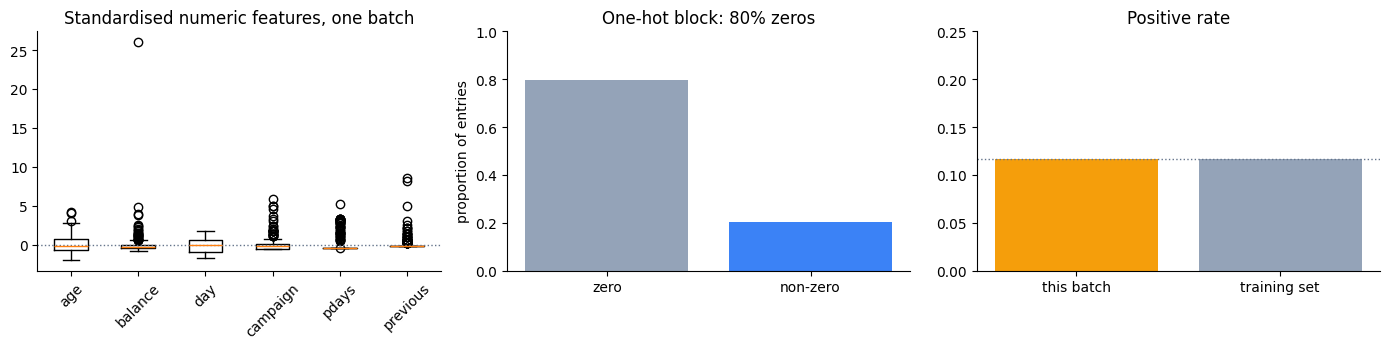

Batch positive rate 0.1172 vs training set 0.1170
One-hot block is 80% zeros — expected, since each
categorical column contributes exactly one 1 across its indicator columns.


In [32]:
xb, yb = next(iter(train_loader))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# Distribution of standardised numeric features.
num_idx = [feature_names.index(c) for c in numeric_cols]
axes[0].boxplot([xb[:, i].numpy() for i in num_idx], tick_labels=numeric_cols, vert=True)
axes[0].axhline(0, color="#64748b", linestyle=":", linewidth=1)
axes[0].set_title("Standardised numeric features, one batch")
axes[0].tick_params(axis="x", rotation=45)

# How sparse is the one-hot block?
onehot_idx = [i for i in range(len(feature_names)) if i not in num_idx]
sparsity = (xb[:, onehot_idx] == 0).float().mean().item()
axes[1].bar(["zero", "non-zero"], [sparsity, 1 - sparsity], color=["#94a3b8", "#3b82f6"])
axes[1].set_ylim(0, 1)
axes[1].set_title(f"One-hot block: {sparsity * 100:.0f}% zeros")
axes[1].set_ylabel("proportion of entries")

# Class balance in this batch versus overall.
axes[2].bar(["this batch", "training set"], [yb.mean().item(), y_tr.mean()],
            color=["#f59e0b", "#94a3b8"])
axes[2].axhline(y_tr.mean(), color="#64748b", linestyle=":", linewidth=1)
axes[2].set_ylim(0, 0.25)
axes[2].set_title("Positive rate")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Batch positive rate {yb.mean():.4f} vs training set {y_tr.mean():.4f}")
print(f"One-hot block is {sparsity * 100:.0f}% zeros — expected, since each")
print(f"categorical column contributes exactly one 1 across its indicator columns.")

### Saving the processed splits

The next note needs the processed training, validation, and test arrays.

Saving them to an `.npz` file means we do not have to download and preprocess the Bank Marketing dataset again every time Note 2.3 starts.

This is simply a convenience and a speed improvement.

The important thing is that we save the **already processed splits**, not a new split each time. That keeps the experiments consistent.


In [33]:
PROCESSED = DATA_DIR / "bank_processed.npz"

np.savez_compressed(
    PROCESSED,
    X_train=Xtr_enc, y_train=y_tr,
    X_val=Xva_enc, y_val=y_va,
    X_test=Xte_enc, y_test=y_te,
    feature_names=np.array(feature_names, dtype=object),
)

size_mb = PROCESSED.stat().st_size / 1e6
print(f"Saved {PROCESSED} ({size_mb:.1f} MB)")

check = np.load(PROCESSED, allow_pickle=True)
print(f"\nContents:")
for key in check.files:
    print(f"  {key:<14} {check[key].shape} {check[key].dtype}")

Saved data/bank_processed.npz (0.6 MB)

Contents:


  X_train        (31647, 50) float32
  y_train        (31647,) int64
  X_val          (6782, 50) float32
  y_val          (6782,) int64
  X_test         (6782, 50) float32
  y_test         (6782,) int64
  feature_names  (50,) object


**Questions to sit with**

1. The project uses labels shaped `(N, 1)`. Another perfectly valid design is `(N,)`. Either can work if the model output and loss calculation use the same convention. The important engineering lesson is consistency: choose one shape and use it everywhere.
2. One-hot encoded data contains many zeros. For a rare category such as `job=student`, most examples have a zero in that category's input column. That means the corresponding input feature is active only for the examples where the category is present. The first-layer weights connected to that feature therefore receive useful input-driven gradient contributions mainly from those examples.


## 8. Conclusion

The complete data pipeline now looks like this:

```text
raw data
   ↓
split into train / validation / test
   ↓
fit preprocessing using TRAIN only
   ↓
transform all splits using the training rules
   ↓
Dataset
   ↓
DataLoader
   ↓
batches
   ↓
training loop
   ↓
model
```

The key ideas are:

- **Mini-batching:** divide the training data into smaller groups so the model can update its parameters many times during one epoch.
- **Split first:** validation and test data must remain unseen when preprocessing rules are learned.
- **Encoding:** categorical values must be converted into numerical representations that do not invent false relationships.
- **Dataset:** answers two questions—"how many examples are there?" and "give me example `i`."
- **Lazy loading:** a dataset can read examples from disk only when they are needed.
- **Transforms:** training can use random augmentation; validation and test should normally use deterministic transformations.
- **DataLoader:** groups individual examples into batches and controls ordering and batch construction.
- **`shuffle=True` for training:** prevents the training process from depending on the original ordering of examples.
- **`shuffle=False` for validation/test:** keeps evaluation stable and predictable.
- **`drop_last`:** can discard an incomplete training batch, but should not be used casually for evaluation.
- **`num_workers`:** can speed up expensive data loading, but more workers are not automatically better.
- **Inspect the first batch:** verify shapes, dtypes, values, and labels before spending time training.

One final habit is especially valuable:

> **Before training a model, inspect one batch and verify that it is exactly what the model expects.**

If the data entering the model is wrong, a better neural network will not fix the problem.

### Transition to Note 2.3

At this point, the data pipeline is ready.

We have:

```text
correctly split data
      ↓
correctly encoded features
      ↓
Dataset
      ↓
DataLoader
      ↓
validated batches
```

What we do **not** have yet is the neural network that will learn from those batches.

Note 2.3 will build that model and train it using these exact loaders.

It will introduce:

- `nn.Module` for defining neural networks;
- forward passes through the network;
- how tensor shapes change from layer to layer;
- the choice between one output value (**one logit**) and two output values;
- a proper training loop;
- `model.train()` and `model.eval()`;
- `torch.no_grad()` during validation;
- validation metrics and baseline comparisons.

The goal is not to assume that a neural network must beat every other model. The goal is to train it correctly and then measure what it actually achieves.
